1. Process Running?
Before checking the network, you must ensure the application is actually alive in the operating system.

Command: ps aux | grep <app_name>

Alternative (Service): sudo systemctl status <service_name>

Why: If the process isn't in the process table, no ports will be open.

---
ps aux | grep nginx

---

manojcloudvm@instance-20260404-024439:~$ ps aux | grep nginx
root        5180  0.0  0.2  10800  8156 ?        S    Apr04   0:00 nginx: master process /usr/sbin/nginx -g daemon on; master_process on;
www-data   94790  0.0  0.1  11240  7544 ?        S    01:57   0:00 nginx: worker process
www-data   94791  0.0  0.1  11208  6376 ?        S    01:57   0:00 nginx: worker process
manojcl+  158727  0.0  0.0   3752  1860 pts/0    S+   21:03   0:00 grep nginx
manojcloudvm@instance-20260404-024439:~$ 





2. Port Listening?
Once the process is confirmed, verify it has successfully "bound" to a network port to accept traffic.

Command: ss -tulpn | grep :<port_number>

Old school: netstat -tulpn

Why: A process might be "Running" but crashed during the socket binding phase (e.g., address already in use).

---
sudo ss -tulpn | grep nginx 
---
manojcloudvm@instance-20260404-024439:~$ sudo ss -tulpn | grep nginx
tcp   LISTEN 0      511            0.0.0.0:443        0.0.0.0:*    users:(("nginx",pid=94791,fd=19),("nginx",pid=94790,fd=19),("nginx",pid=5180,fd=19)) 
tcp   LISTEN 0      511            0.0.0.0:80         0.0.0.0:*    users:(("nginx",pid=94791,fd=5),("nginx",pid=94790,fd=5),("nginx",pid=5180,fd=5))    
tcp   LISTEN 0      511               [::]:443           [::]:*    users:(("nginx",pid=94791,fd=20),("nginx",pid=94790,fd=20),("nginx",pid=5180,fd=20)) 
tcp   LISTEN 0      511               [::]:80            [::]:*    users:(("nginx",pid=94791,fd=6),("nginx",pid=94790,fd=6),("nginx",pid=5180,fd=6))  

3. Reachable?
Check if the network path between the client and the server is open (Firewalls, Routing).

Basic connectivity: ping <ip_address>

Path trace: traceroute <ip_address>

Port specific (Best): nc -zv <ip_address> <port> (Netcat) or telnet <ip_address> <port>

Why: In GCP, your app might be fine, but the VPC Firewall could be blocking the traffic.

---
ping is only for IP address, not IP:port. So this is wrong: ping 0.0.0.0:443
---

manojcloudvm@instance-20260404-024439:~$ nc -zv 127.0.0.1 443 
Connection to 127.0.0.1 443 port [tcp/https] succeeded!
manojcloudvm@instance-20260404-024439:~$ nc -zv 127.0.0.1 80
Connection to 127.0.0.1 80 port [tcp/http] succeeded!

6. Dependency Healthy?
Finally, if the app is "up" but returning errors, check the services it relies on (Upstream).

Command: tail -f /var/log/nginx/error.log or tail -f ~/infra-lab/app1/app1.log

Why: You are looking for "Connection refused" or "Upstream timed out" errors. In your lab, this is where you'd see App1 complaining that App2 (port 5001) is down.
---
If Nginx is up but app is failing:
sudo tail -f /var/log/nginx/error.log

Or app-specific logs:

tail -f ~/infra-lab/app1/app1.log
tail -f ~/infra-lab/app2/app2.log

Look for:
connection refused
upstream timed out
no live upstreams
---



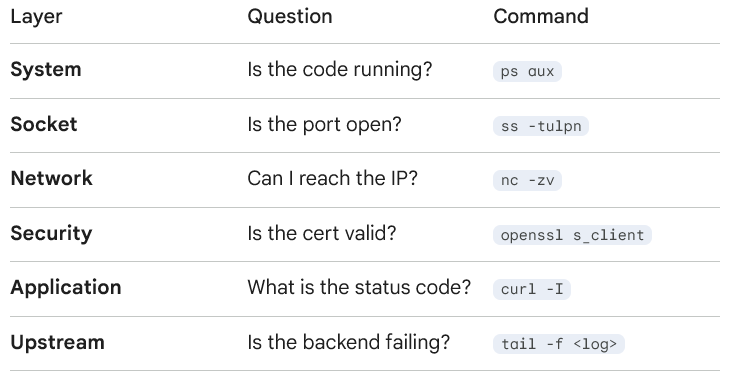


Final minimal flow for Nginx
ps aux | grep nginx

sudo ss -tulpn | grep nginx

nc -zv 127.0.0.1 80

nc -zv 127.0.0.1 443

openssl s_client -connect 127.0.0.1:443 -servername localhost

curl -iv http://127.0.0.1/

curl -ivk https://127.0.0.1/

sudo tail -f /var/log/nginx/error.log

Big idea:

ps = process alive?

ss = port bound?

nc = port reachable?

openssl = TLS works?

curl = HTTP response okay?

logs = why failing?
